# Model Evaluation

## Objective

The objective of this notebook is to evaluate the performance of all trained machine learning models using various evaluation metrics. The results will help identify the most suitable model for credit card fraud detection.

In [24]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv("../data/processed/processed_creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996823,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,0
1,-1.996823,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,0
2,-1.996802,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,0
3,-1.996802,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,0
4,-1.996781,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,0


The processed dataset was successfully loaded for model evaluation.

## Preparing Features and Targate

In [26]:
X = df.drop("Class", axis=1)

Y = df["Class"]

## Splitting Training data and Testing data 
 - Should be exactly as in notebook 4

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
)

## Loading trained Models

In [28]:
logistic_model = joblib.load("../models/logistic_regression.pkl")

decision_tree = joblib.load("../models/decision_tree.pkl")

random_forest = joblib.load("../models/random_forest.pkl")

gradient_boost = joblib.load("../models/gradient_boosting.pkl")

All trained models were loaded successfully

# Making Predictions

In [29]:
logistic_pred = logistic_model.predict(X_test)

decision_tree_pred = decision_tree.predict(X_test)

random_forest_pred = random_forest.predict(X_test)

gradient_boost_pred = gradient_boost.predict(X_test)

Making a reevaluation function

In [30]:
def evaluate_model(model_name, y_true, y_pred):
    
    accuracy = accuracy_score(y_true, y_pred)
    
    precision = precision_score(y_true, y_pred)
    
    recall = recall_score(y_true, y_pred)
    
    f1 = f1_score(y_true, y_pred)
    
    auc = roc_auc_score(y_true, y_pred)

    print(f"\n{model_name}")
    print("-" * 40)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    
    return [
        model_name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]

## Evaluating each model

In [31]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        Y_test,
        logistic_pred
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        Y_test,
        decision_tree_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        Y_test,
        random_forest_pred
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        Y_test,
        gradient_boost_pred
    )
)


Logistic Regression
----------------------------------------
Accuracy : 0.9776
Precision: 0.0597
Recall   : 0.8889
F1 Score : 0.1119
ROC-AUC  : 0.9333

Decision Tree
----------------------------------------
Accuracy : 0.9989
Precision: 0.6552
Recall   : 0.6333
F1 Score : 0.6441
ROC-AUC  : 0.8164

Random Forest
----------------------------------------
Accuracy : 0.9996
Precision: 0.9577
Recall   : 0.7556
F1 Score : 0.8447
ROC-AUC  : 0.8778

Gradient Boosting
----------------------------------------
Accuracy : 0.9993
Precision: 0.9048
Recall   : 0.6333
F1 Score : 0.7451
ROC-AUC  : 0.8166


In [32]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.977620,0.059701,0.888889,0.111888,0.933325
1,Decision Tree,0.998890,0.655172,0.633333,0.644068,0.816402
2,Random Forest,0.999559,0.957746,0.755556,0.844720,0.877751
3,Gradient Boosting,0.999313,0.904762,0.633333,0.745098,0.816614


Selecting the best model using this Comparision table above

In [33]:
best_model = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

best_model

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.999559,0.957746,0.755556,0.844720,0.877751
3,Gradient Boosting,0.999313,0.904762,0.633333,0.745098,0.816614
1,Decision Tree,0.998890,0.655172,0.633333,0.644068,0.816402
0,Logistic Regression,0.977620,0.059701,0.888889,0.111888,0.933325


# Observation
The models were successfully compared using multiple evaluation metrics. The model with the highest F1 Score will be selected as the final model for the project.

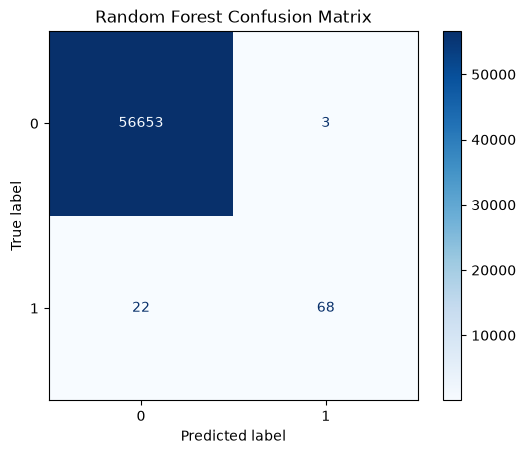

In [34]:
ConfusionMatrixDisplay.from_estimator(
    random_forest,
    X_test,
    Y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

# Final Summary

- Loaded all trained machine learning models.
- Generated predictions using the testing dataset.
- Evaluated each model using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
- Compared the performance of all models.
- Selected the best-performing model based on evaluation metrics.